In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
train = pd.read_csv("open/train.csv")
test = pd.read_csv("open/test.csv")
submission = pd.read_csv("open/sample_submission.csv")

### Data 시각화

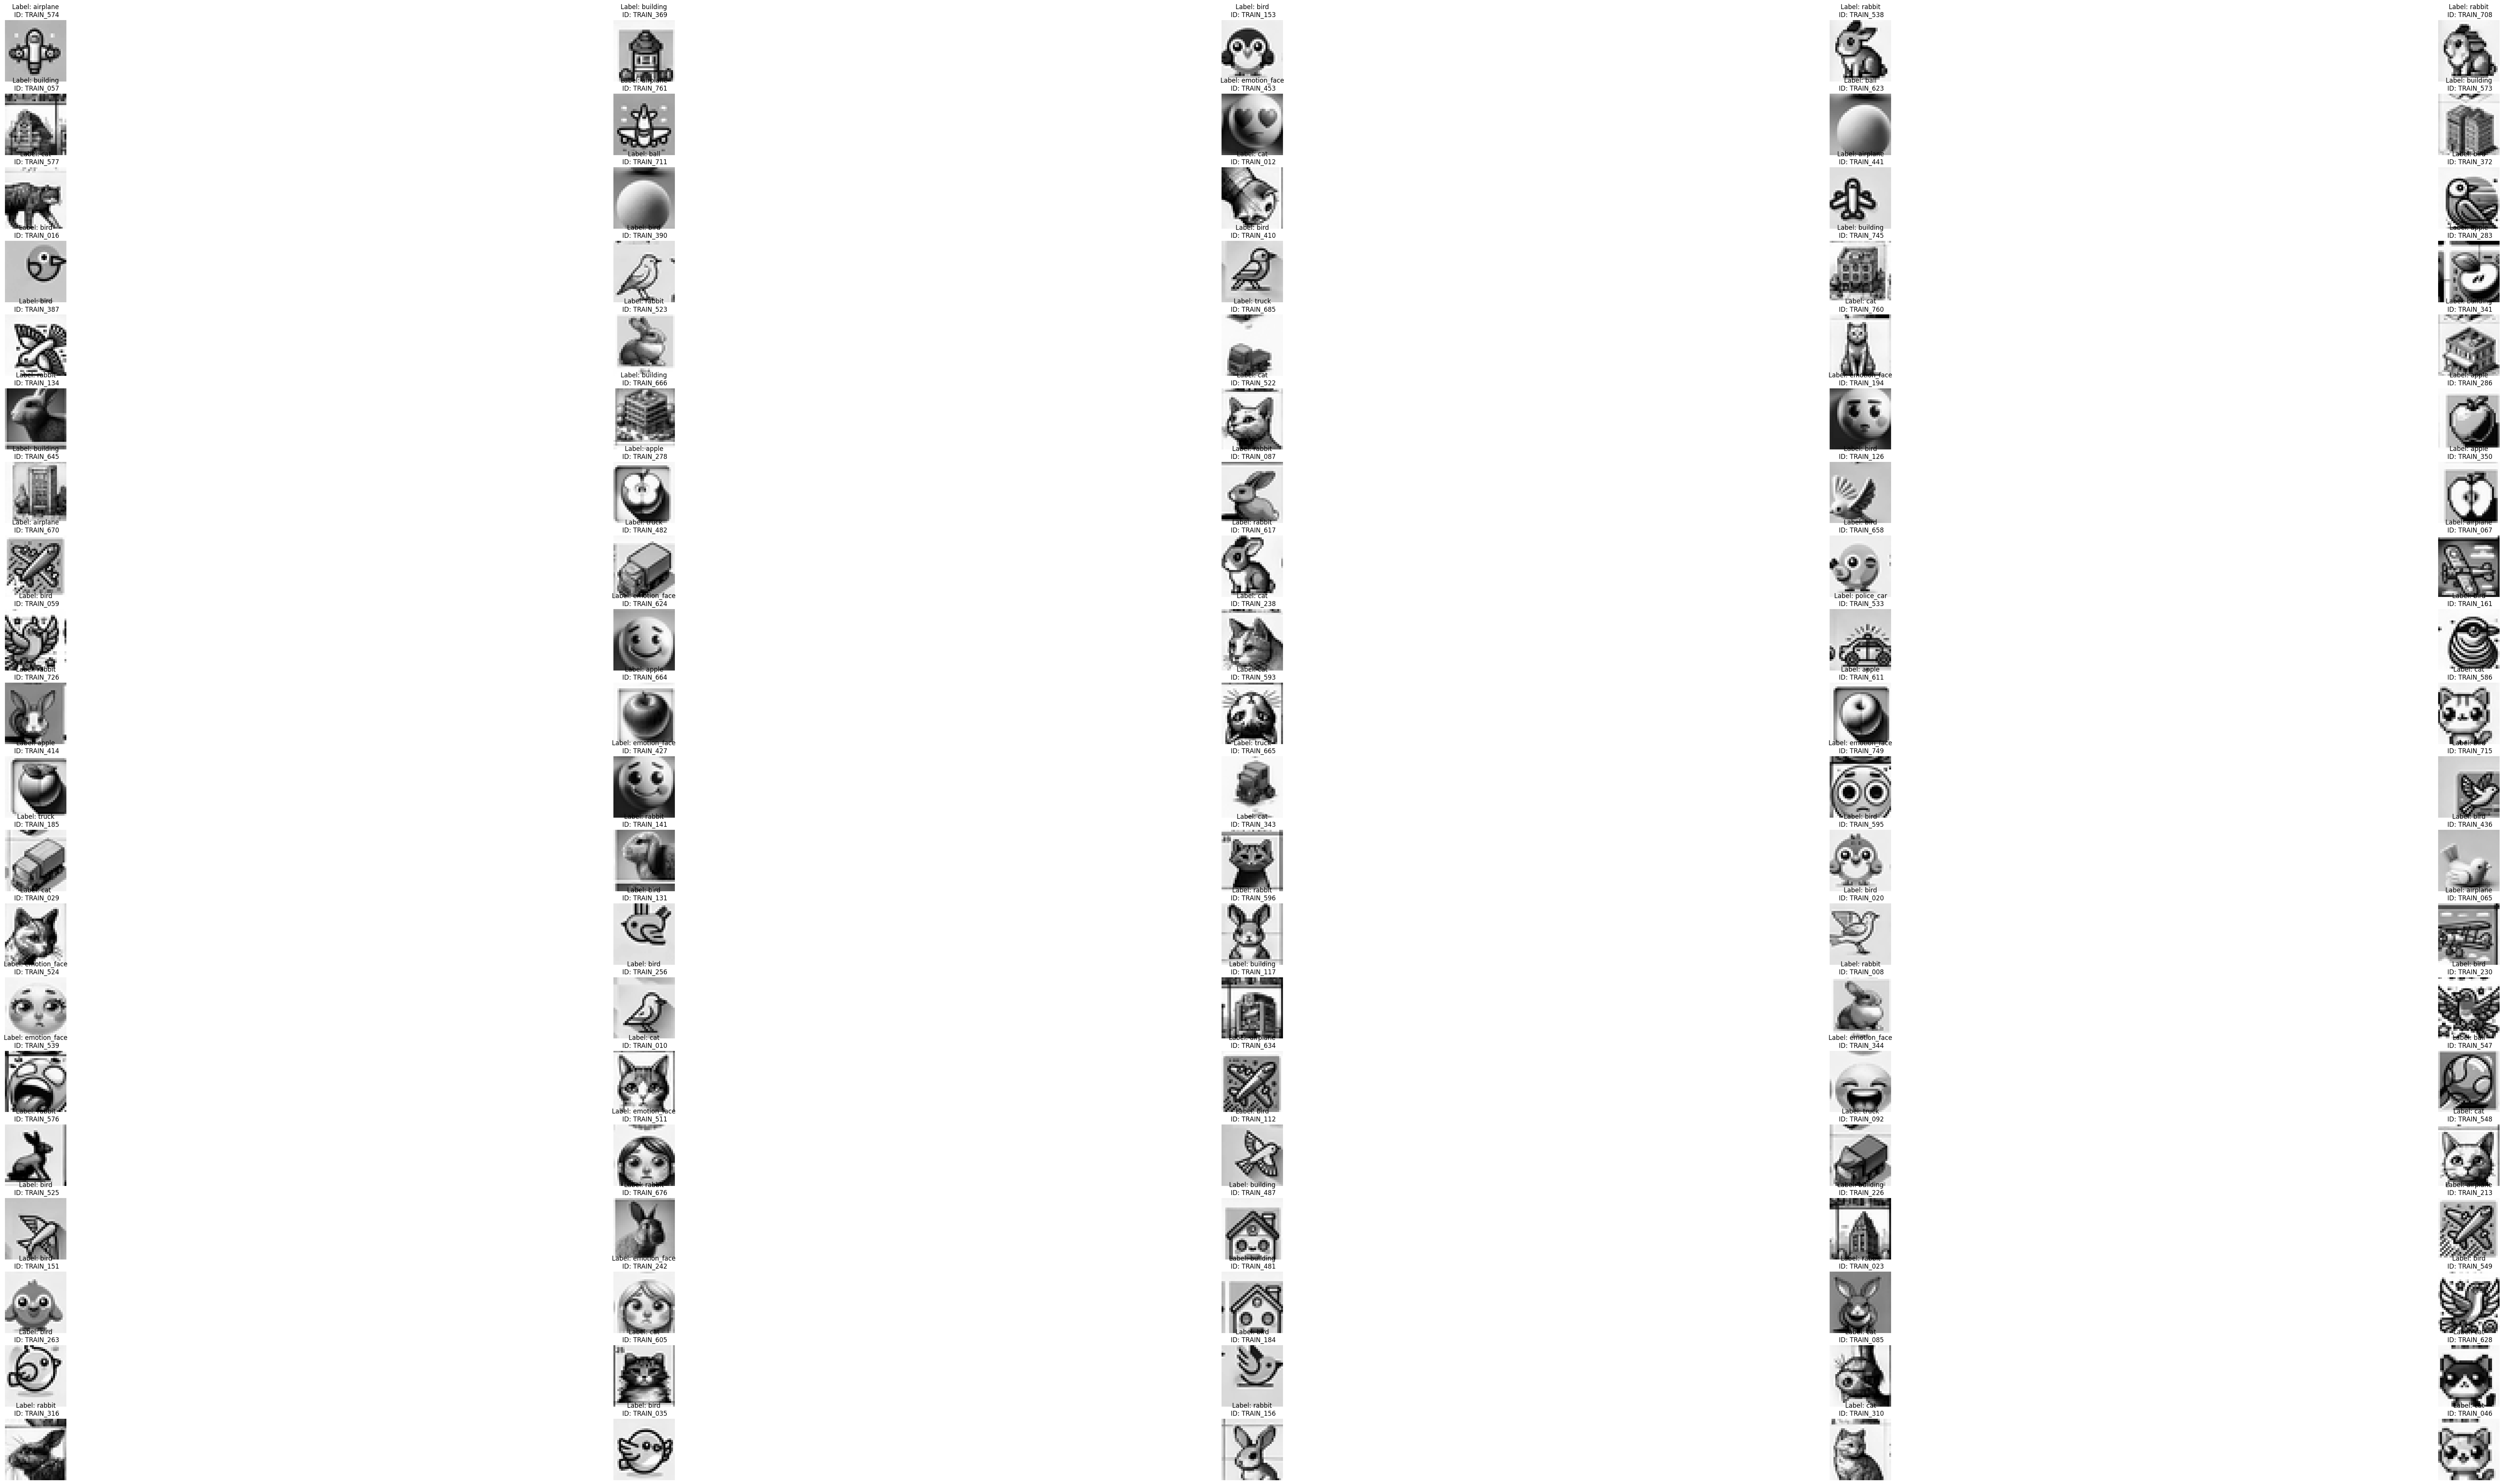

In [5]:
random_indices = np.random.choice(len(train), 100, replace=False)
samples = train.iloc[random_indices]

fig, axes = plt.subplots(20, 5, figsize=(100, 50))
for i, (idx, sample) in enumerate(samples.iterrows()):
    image = sample.iloc[2:].values.astype(np.uint8).reshape(32,32)

    row, col = divmod(i, 5)
    axes[row, col].imshow(image, cmap='gray')
    axes[row, col].set_title(f"Label: {sample['label']}\n ID: {sample['ID']}")
    axes[row, col].axis("off")

### Dataset 구성

In [8]:
import torch
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from transformers import ViTForImageClassification, ViTConfig
import torch.nn as nn
import torch.optim as optim
import time

/home/qkboo/.pyenv/versions/3.12.1/envs/Goodyoung_P312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Config

In [16]:
from dataclasses import dataclass
@dataclass
class TrainingConfig:
    image_size = 224  # 생성되는 이미지 해상도
    batch_size = 32
    num_epochs = 400
    learning_rate = 5e-5
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    seed = 42
    weights_name = f"vit-baseline-epoch-{num_epochs}-2.pth"
    num_labels = 10
    in_channel = 1
    early_stop_epoch = 40
    
config = TrainingConfig()

In [10]:
label_encoder = LabelEncoder()
train["label"] = label_encoder.fit_transform(train["label"])  # 문자열 라벨을 숫자로 변환

In [11]:
train_idx, val_idx = train_test_split(train.index, test_size=0.2, stratify=train["label"], random_state=config.seed)

### Dataset 구성

In [12]:
class CustomDataset(Dataset):
    def __init__(self, df, transform=None, test=False):
        self.df = df
        self.transform = transform
        self.test = test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # test=True일 경우, label 컬럼이 없을 수도 있으므로 예외 처리
        if self.test:
            image = row.values.astype(np.uint8).reshape(32, 32)  # ID 이후부터 픽셀 값
        else:
            image = row.iloc[2:].values.astype(np.uint8).reshape(32, 32)  # ID, label 이후부터 픽셀 값
            label = row["label"]

        if self.transform:
            image = self.transform(image)

        return image if self.test else (image, label)  # test=True면 image만 반환


In [13]:
# transform = transforms.Compose([
#     transforms.ToPILImage(),  # NumPy 배열을 PIL 이미지로 변환
#     transforms.Resize((config.image_size, config.image_size)),  # ViT 입력 크기로 조정
#     transforms.ToTensor(),  # PyTorch Tensor 변환
#     transforms.Normalize(mean=[0.5], std=[0.5])  # 정규화
# ])
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((config.image_size, config.image_size)),
    transforms.RandomHorizontalFlip(p=0.5),  # 50% 확률로 좌우 반전
    transforms.RandomVerticalFlip(p=0.2),  # 20% 확률로 상하 반전 (너무 강한 반전 방지)
    transforms.RandomRotation(degrees=(-15, 15)),  # 제한된 각도 회전
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_dataset = CustomDataset(df = train.iloc[train_idx, :], transform=transform)
val_dataset = CustomDataset(df = train.iloc[val_idx, :], transform=transform)
test_dataset = CustomDataset(df = test.iloc[:, 1:], transform=transform, test = True)

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False)

Batch Image Shape: torch.Size([32, 1, 224, 224])
Batch Labels Shape: torch.Size([32])


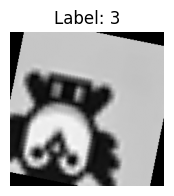

In [17]:
# DataLoader 검증
train_batch = next(iter(train_loader))  
images, labels = train_batch
print(f"Batch Image Shape: {images.shape}")  
print(f"Batch Labels Shape: {labels.shape}")  

plt.figure(figsize=(3,2))
plt.imshow(images[0].permute(1, 2, 0), cmap="gray",)
plt.title(f"Label: {labels[0].item()}")  
plt.axis("off")
plt.show()

In [18]:
vit_config = ViTConfig.from_pretrained("google/vit-base-patch16-224-in21k")
vit_config.num_channels = config.in_channel  # 입력 채널을 1로 변경
vit_config.num_labels=config.num_labels

model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224-in21k",
    ignore_mismatched_sizes=True,
    config = vit_config
)

model.to(config.device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=config.learning_rate)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.num_epochs)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    train_loss = 0.0
    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(pixel_values=images).logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0) # 마지막 배치 크기가 작아도 정확하게 반영됨.
        
    one_epoch_loss = train_loss / len(loader.dataset)
    return one_epoch_loss

@torch.no_grad()
def val_one_epoch(model, loader, criterion, device):
    model.eval()
    val_loss, correct, total = 0, 0, 0
    
    for images, labels in tqdm(loader, desc="Validation", leave=False):
        images, labels = images.to(device), labels.to(device)
        outputs = model(pixel_values=images).logits
        loss = criterion(outputs, labels)

        val_loss += loss.item() * images.size(0)
        
        _, predicted = outputs.max(1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
            
    one_epoch_loss = val_loss / len(loader.dataset)
    acc = correct / total
    return one_epoch_loss, acc

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized because the shapes did not match:
- embeddings.patch_embeddings.projection.weight: found shape torch.Size([768, 3, 16, 16]) in the checkpoint and torch.Size([768, 1, 16, 16]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# train loop
best_loss = 1e9
best_model = None
early_stop_num = 0  # 개선되지 않은 epoch 수 카운트

for epoch in range(config.epoch):
    start_time = time.time()
    # train
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, config.device)
    val_loss, val_acc = val_one_epoch(model, train_loader, criterion, config.device)
    
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Accuracy: {val_acc*100:.2f}%")

    # Check for best model
    if val_loss < best_loss:
        print(f'Epoch:{epoch} | Best: {val_loss}')
        torch.save(model.state_dict(), f"weights/{config.weights_name}")
        best_loss = val_loss
        best_model = model
        early_stop_num = 0
    else:
        early_stop_num += 1
        
    if early_stop_num == config.early_stop_epoch:
        print(f"Early Stopping :{epoch}")
        break  # 학습 중단
    scheduler.step()

Train Loss: 0.0027 | Val Loss: 0.0027 | Val Accuracy: 100.00%
Epoch:0 | Best: 0.0027042362903343226


Train Loss: 0.0027 | Val Loss: 0.0027 | Val Accuracy: 100.00%
Epoch:1 | Best: 0.0026635399459278195


Train Loss: 0.0027 | Val Loss: 0.0026 | Val Accuracy: 100.00%
Epoch:2 | Best: 0.002634581815209088


Train Loss: 0.0026 | Val Loss: 0.0026 | Val Accuracy: 100.00%
Epoch:3 | Best: 0.0026291772821630402


Train Loss: 0.0026 | Val Loss: 0.0026 | Val Accuracy: 100.00%
Epoch:4 | Best: 0.002581922510805411


...

Train Loss: 0.0012 | Val Loss: 0.0012 | Val Accuracy: 100.00%


Train Loss: 0.0012 | Val Loss: 0.0012 | Val Accuracy: 100.00%
Epoch:194 | Best: 0.0012036147752655594


Train Loss: 0.0012 | Val Loss: 0.0012 | Val Accuracy: 100.00%


Train Loss: 0.0012 | Val Loss: 0.0012 | Val Accuracy: 100.00%


Validation:  45%|████▌     | 9/20 [00:01<00:01,  8.76it/s]

### Inference

In [20]:
best_model.eval()
preds = []

with torch.no_grad():
    for images in tqdm(test_loader, desc="Inference", leave=False):
        images = images.to(config.device)
        outputs = best_model(images)
        _, predicted = torch.max(outputs.logits, 1)
        preds.extend(predicted.cpu().numpy())

# Decode predictions
pred_labels = label_encoder.inverse_transform(preds)

### Submission

In [21]:
submission['label'] = pred_labels
submission.to_csv('baseline_submission3.csv', index=False)